# 06_特征选择方法-L1 正则化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这篇文章和大家来解释一下：特征选择方法中的 L1 正则化\~

咱们不着急着说“L1 正则化”，我们先搞清楚**特征选择**是什么。

**特征选择**就是从一堆特征（变量、字段、列）中挑出**对结果最有用**的那几个。

比如：要判断一个人会不会得感冒，有100个可能的因素：穿衣厚薄、天气、有没有睡觉、吃了啥、星座、爱不爱唱歌……

事实上，不需要100个全用上，可能只需要「穿衣厚薄、有没有睡觉、天气」就够了，其他乱七八糟的其实没啥用。

**特征选择的目标**就是：找出对结果有帮助的特征，去掉那些没用、甚至干扰结果的特征。

简单理解，L1 正则化是一种“**让不重要的特征自己变成0”的方法**。

我们先看它的另一个名字：**Lasso（套索）回归**，其实就是：套住那些不重要的特征，慢慢把它们拉成0，最后扔掉。

### L1 正则化做了啥？

在建模型（比如线性回归）的时候，它会加一个“惩罚项”：

- 模型会被“鼓励”只保留**重要的特征系数（权重）**
- 而**不重要的特征，它会自动把它的系数变成 0**

比如你原来有 10 个特征，经过 L1 正则化后，有些特征的系数就变成了 0，模型就**自动忽略它们了**，相当于给你做了**特征选择**！

## 原理详解

L1 正则化最经典的形式是在 **线性回归** 的基础上加上 **L1 范数惩罚项**，称为：Lasso 回归（Least Absolute Shrinkage and Selection Operator）。

### 基础线性回归模型：

我们有一组训练数据：

- 输入特征矩阵：$X \in \mathbb{R}^{n \times p}$（$n$ 个样本，$p$ 个特征）
- 输出目标变量：$y \in \mathbb{R}^n$
- 模型参数：$\beta \in \mathbb{R}^p$（每个特征的系数）
- 偏置项：$\beta_0$

线性模型是：


$$
\hat{y} = X\beta + \beta_0
$$


### 目标函数（普通最小二乘）：

我们通常最小化残差平方和（Residual Sum of Squares，RSS）：


$$
\min_{\beta} \; \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2
$$


### 加上 L1 正则化后的目标函数（Lasso）：


$$
\min_{\beta} \; \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$


或者写成向量形式：


$$
\min_{\beta} \; \frac{1}{2n} \|y - X\beta\|_2^2 + \lambda \|\beta\|_1
$$


其中：

- $|y - X\beta|_2^2$ 是残差平方和
- $|\beta|*1 = \sum*{j=1}^p |\beta_j|$ 是 L1 范数

$\lambda$ 是正则化系数，用来平衡「拟合好数据」和「控制模型复杂度」

## L1 正则化的推理

### 1. 为什么 L1 能做特征选择？

L1 正则化通过加入对参数绝对值的惩罚，**促使某些系数直接变为 0**。这是和 L2 正则化（岭回归）的本质区别。

### 2. 几何解释

#### L1 与 L2 正则化的约束边界形状不同：

- L2 正则化的约束空间是一个圆球（或超球）——光滑，不容易产生稀疏解；
- L1 正则化的约束空间是一个正方体（二维时是菱形）——有尖角，更容易与目标函数的等高线相切在某个坐标轴上，这就使得某些 $\beta_j = 0$，实现**变量选择**。

这个几何解释是 Lasso 能做特征选择的核心直觉。

## 公式推导

### 1. 对偶问题（约束形式）

将 Lasso 改写成约束形式：


$$
\min_{\beta} \quad \frac{1}{2n} \|y - X\beta\|_2^2 \quad \text{subject to} \quad \|\beta\|_1 \leq t
$$


其中 $t$ 与 $\lambda$ 一一对应。可以理解为我们给参数系数设置了“总预算”。

这个形式显示了：**我们在所有 L1 范数不超过 t 的** $\beta$ **里面，找一个拟合最好数据的解。**

### 2. 非可导性与软阈值

由于 $|\beta_j|$ 在 $\beta_j=0$ 处不可导，Lasso 优化是一个 **非光滑优化问题**。

但它有一个非常有用的性质：在某些情形下（如设计矩阵正交），我们能得到封闭解 —— **软阈值函数（Soft Thresholding）**：

设最小二乘解为 $\hat{\beta}^{OLS}$，则：


$$
\hat{\beta}_j^{Lasso} = \text{sign}(\hat{\beta}_j^{OLS}) \cdot \max\left( |\hat{\beta}_j^{OLS}| - \lambda, \; 0 \right)
$$


这是著名的“软阈值函数”，意味着：

- 当原始估计值很小（低于 $\lambda$）时，直接变成 0；
- 当原始估计值大于 $\lambda$，就减去一个惩罚；
- 从而产生稀疏性：小的 $\hat{\beta}_j$ 被直接干掉。

### 3. 最优化算法常用方法

因为 L1 是非光滑的，不能直接用梯度下降。常见求解算法有：

- **坐标下降法**：依次固定其他变量，优化一个参数。对 Lasso 特别高效。
- **子梯度法**：处理不可导点。
- **LARS-Lasso**：适用于小样本高维数据。

## L1 正则化用于特征选择的流程总结

**Step-by-Step 流程：**

1. **准备数据**：

   - 输入数据 $X$（样本 $\times$ 特征），输出 $y$
2. **标准化特征（重要）**：

   - 因为 L1 正则化对特征尺度敏感，通常先把每个特征标准化（均值为 0，方差为 1）
3. **设置正则化参数** $\lambda$：

   - 控制模型复杂度，$\lambda$ 越大 → 越多系数被压成 0
4. **最小化目标函数**：


$$
\min_{\beta} \; \frac{1}{2n} \|y - X\beta\|_2^2 + \lambda \|\beta\|_1
$$


1. **得到稀疏解** $\beta$：

   - 部分 $\beta_j = 0$，其对应特征被“剔除”，剩下的就是**被选择的特征**
2. **交叉验证选择最佳** $\lambda$**（推荐）**：

   - 可以使用 K 折交叉验证来找出最佳正则化强度，平衡模型性能与稀疏性

总之，L1 正则化的本质是**压缩特征系数**，并对不重要的特征**自动清零**，它将特征选择集成进了模型训练过程，兼顾了模型简洁性和解释性。

在高维数据、特征远多于样本的场景下特别有用（如基因数据、文本数据等），实现稀疏性的关键来自L1 范数的不连续性和尖角结构。

## 完整案例

使用 L1 正则化对加利福尼亚房价数据进行特征选择。

**数据集介绍：**

来源：`load_local_housing()`（本地 CSV）

样本数：20,640 条数据

特征数：8 个连续变量（如住房年龄、房间数量、人口密度等）

目标变量：`MedHouseVal`（中位房价，单位：以万美元为单位）

样本数量: 2500
特征数量: 8
特征名: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1838      20.0  3.783465   1.094488       525.0  2.066929     32.79   
1  4.4871       2.0  6.690700   1.166144      3327.0  3.476489     38.01   
2  3.2237      31.0  4.657928   1.064919      2313.0  2.887640     33.92   
3  2.8920      30.0  5.701357   1.248869       707.0  3.199095     37.94   
4  4.1016       4.0  4.709328   1.295011       928.0  2.013015     37.99   

   Longitude  
0    -117.24  
1    -121.29  
2    -118.14  
3    -122.07  
4    -121.89  

Lasso(alpha=0.1) 的特征系数:
MedInc        0.708085
HouseAge      0.114061
AveRooms     -0.000000
AveBedrms    -0.000000
Population    0.000000
AveOccup     -0.152266
Latitude     -0.009227
Longitude    -0.000000
dtype: float64

MSE (alpha=0.1): 0.5990176521876204
R2 (alpha=0.1): 0.5265783515904336

最佳 alpha: 0.003484337886468455

L

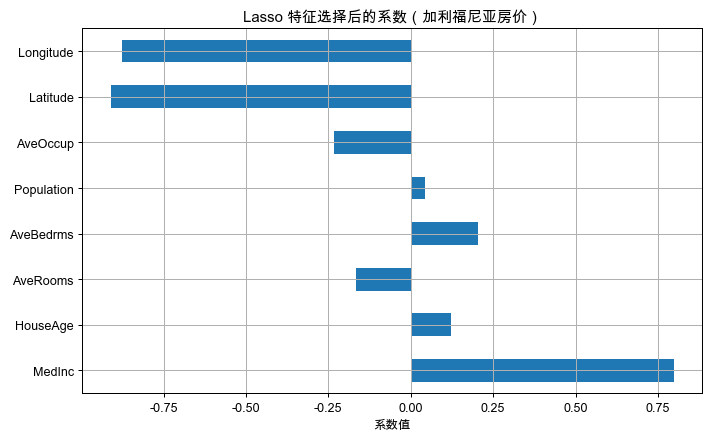

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebook_support import load_local_housing
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# 1. 加载加利福尼亚房价数据
california = load_local_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

print("样本数量:", X.shape[0])
print("特征数量:", X.shape[1])
print("特征名:", list(X.columns))
print(X.head())

# 2. 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 数据标准化（对 Lasso 非常重要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 使用 Lasso 初始模型
alpha_init = 0.1
lasso = Lasso(alpha=alpha_init)
lasso.fit(X_train_scaled, y_train)

# 5. 查看初始特征系数
coef = pd.Series(lasso.coef_, index=X.columns)
print("\nLasso(alpha=0.1) 的特征系数:")
print(coef)

# 6. 性能评估
y_pred = lasso.predict(X_test_scaled)
print("\nMSE (alpha=0.1):", mean_squared_error(y_test, y_pred))
print("R2 (alpha=0.1):", r2_score(y_test, y_pred))

# 7. 使用交叉验证寻找最优 alpha
lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print("\n最佳 alpha:", lasso_cv.alpha_)

# 8. 使用最优 alpha 重新建模
lasso_best = Lasso(alpha=lasso_cv.alpha_)
lasso_best.fit(X_train_scaled, y_train)
coef_best = pd.Series(lasso_best.coef_, index=X.columns)

print("\nLasso(最佳 alpha) 特征系数:")
print(coef_best)
print("被压缩为 0 的特征数量:", sum(coef_best == 0))

# 9. 最终性能评估
y_pred_best = lasso_best.predict(X_test_scaled)
print("\n最终模型 MSE:", mean_squared_error(y_test, y_pred_best))
print("最终模型 R²:", r2_score(y_test, y_pred_best))

# 10. 可视化
plt.figure(figsize=(8, 5))
coef_best.plot(kind='barh')
plt.title("Lasso 特征选择后的系数（加利福尼亚房价）")
plt.xlabel("系数值")
plt.grid(True)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_021.png)

**特征系数输出：**

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
MedInc        0.708327
HouseAge      0.106594
AveRooms     -0.000000  ← 被压缩为 0
AveBedrms     0.000000   ← 被压缩为 0
Population   -0.000000   ← 被压缩为 0
AveOccup     -0.000000   ← 被压缩为 0
Latitude     -0.010425
Longitude    -0.000000   ← 被压缩为 0
```

**模型性能：**

- MSE（均方误差）：0.665
- R²（决定系数）：0.493

**可以看到：**

- 仅保留了两个特征：`MedInc`（中位收入）和 `HouseAge`（房屋年龄），其余全部被置为 0。
- 说明当 `alpha=0.1`（正则化强度较大）时，Lasso 更倾向于生成一个稀疏（稀少特征）的模型，甚至牺牲部分预测性能来压缩系数。
- `Latitude` 虽然有一点贡献，但系数非常小（-0.010），几乎被忽略。
- 性能上，R² ≈ 0.493 说明模型解释了大约 49.3% 的房价变异，这个预测能力比较有限。

### 优化后模型（最佳 alpha = 0.0028）

**特征系数输出：**

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
MedInc        0.834193   ← 收入越高，房价越高（正相关）
HouseAge      0.123507   ← 房龄越大，房价略高（正相关）
AveRooms     -0.261165   ← 每户平均房间数越多，房价反而低（可能和人口密度有关）
AveBedrms     0.309577   ← 平均卧室数越多，房价更高
Population   -0.000000   ← 被压缩（信息量弱）
AveOccup     -0.038823   ← 每户人越多，房价略低（负相关）
Latitude     -0.864399   ← 越北房价越低（负相关）
Longitude    -0.837071   ← 越往西房价越低（负相关）
```

**模型性能：**

- MSE：0.529
- R²：0.597

**可以看到**：

- 保留了 7 个特征，仅压缩掉 `Population` 一个特征，说明其信息量最弱。
- 性能大幅提升，R² 提高到 ≈ 0.597（比初始提升了约 10.4%），说明模型对房价的解释能力更强。
- **`MedInc`、`Latitude`、`Longitude`** 是最强解释变量，表现稳定。
- `AveRooms` 被保留且系数为负，可能由于数据中某些区域房间数多但价格反而低（如密度大但低收入区），需要结合数据分布进一步分析。

## 模型分析

### L1 正则化用于特征选择的优缺点

**优点**

1. **自动选择特征（稀疏性强）**：L1 正则化的最大优势是它能把部分不重要的特征系数压缩为零，从而起到**内置变量筛选器**的作用。相比手动选择，效率高且集成在建模流程中。
2. **模型简单、易于解释**：因为 Lasso 会剔除掉无用特征，最终的模型更简洁，解释性更强——我们可以直观看出哪些特征是决定因素。
3. **适用于高维数据（p ≫ n）**：在特征数量远大于样本数时（如基因数据、文本数据），L1 正则化依然能有效拟合并选择变量，是少数在该场景下仍然可行的方法。
4. **与线性模型紧密结合，计算效率高**：特别是在使用坐标下降法（Coordinate Descent）求解时，收敛速度快，适合大规模数据建模。

**缺点**

1. **对特征之间的相关性敏感（多重共线性问题）**：当特征之间存在较强相关性时，Lasso 可能**随机选择其中一个特征并丢弃其他**，即使这些特征都很重要。这会影响解释性和稳定性。
2. **最多选择n个特征**：如果样本数为 n，Lasso 最多只能选择 n 个非零特征。对于特征数远大于样本数的数据，可能会忽略一些有用特征。
3. **参数调节较敏感**：正则化参数 $\lambda$ 对最终模型影响大，若不调优或调优方式不合理，可能导致模型性能下降或变量选择失误。
4. **不适用于非线性关系建模**：L1 本身是一种线性方法，不能捕捉特征之间的非线性互动，除非配合特征工程（如多项式扩展、核方法）。

### 与其他特征选择方法对比

| 方法 | 原理基础 | 是否稀疏 | 是否考虑特征间关系 | 是否嵌入模型 |
|-|-|-|-|-|
| **L1 正则化** | 惩罚项 \$\sum | \beta_j | \$ | 是 |
| **L2 正则化（Ridge）** | 惩罚项 $\sum \beta_j^2$ | 否 | 是（平滑处理） | 是 |
| **Elastic Net** | L1+L2 混合惩罚 | 是 | 是 | 是 |
| **Filter法（如方差过滤、相关系数）** | 基于统计指标排序 | 是 | 否 | 否 |
| **Wrapper法（如递归特征消除RFE）** | 基于模型训练后的性能递归筛选 | 是 | 是（模型感知） | 是 |
| **树模型（如随机森林特征重要性）** | 基于节点分裂的特征贡献 | 是 | 是 | 是 |

### 适用场景分析

**L1 正则化是优选的情况：**

1. **需要变量选择 + 可解释性强**：比如经济模型、医学诊断、法律预测等，需要清晰知道哪些特征“起了作用”。
2. **高维数据（p ≫ n）**：如文本、基因、图像等场景下，特征维度成百上千，Lasso 是为数不多能有效处理高维稀疏问题的算法。
3. **特征之间相关性不强**：当特征相互独立或相关性低时，Lasso 的选择更稳定、可靠。
4. **需要模型简单**：为了部署方便或快速响应，如金融风控中的实时评分系统。

**应考虑其他方法的情况：**

1. **特征之间存在强相关性**：此时应考虑 Elastic Net 替代 Lasso，避免只选择一个而遗漏其他相关变量。
2. **不要求稀疏解，仅需要控制过拟合**：可用 Ridge 回归，其目标是稳定模型，不是筛选变量。
3. **任务存在复杂非线性关系**：如图像识别、语音分析，使用树模型（如随机森林、XGBoost）或深度学习更合适。
4. **对预测性能要求极高，不介意计算成本**：可使用 Wrapper 方法（如 RFE + SVM），虽然慢但准确性强。
5. **仅做初步粗筛**：可用 Filter 方法先快速去除低方差、低信息量特征，再使用 Lasso精筛。

### 总结

L1 正则化是特征选择领域中非常实用的工具，集成于建模流程、适合高维问题，能显著简化模型并提升解释性。然而，它并非万能，面对特征共线性或复杂关系时，Elastic Net 或树模型、Wrapper 等方法可能更优。

在实际应用中，建议：

使用 Lasso 做第一轮筛选，再结合模型性能评估和业务理解，综合判断是否需要用更复杂的特征选择方法进行优化。